# Build Parameters

Four forms record laser powder-bed fusion process parameters, each with its own field names, its own units, and its own idea of what a row is. This notebook normalizes all four into one frame so process parameters can be compared across programs.

- **Printer Build** — CMU/APL builds, four scan types per build, parameters nested two levels deep
- **NASA Ti64 30um Layers Data** — flat, one row per specimen, already in millimetres
- **Archival ULI Build (simplified)** — flat, infill only, no layer thickness
- **AM Build Parameters** — a list of parameter sets per build, one per scan type

It also fixes a unit bug that has been corrupting the combined dataset, and validates the result against an independently computed energy density.

## Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "imqcam.py").exists())
sys.path.insert(0, str(REPO_ROOT))

from imqcam import explode_records, extract_igsn, fetch_entries, get_client

BLUE, ORANGE, GREEN, PURPLE = "#4C8BE2", "#E26C4C", "#4CE2A7", "#9B7CE2"

PRINTER_BUILD = "66425a71b18fa1c426e93aa0"
NASA_TTT = "67d39472366ec49ab59dd4db"
ULI = "68922e35f5b193b7d3e07f5b"
AM_BUILD = "6970da157f6ebb8fb320705c"

client = get_client()

# One targeted request per form -- `formId` is a server-side filter, so nothing
# from the other forms is fetched and then thrown away.
by_form = {
    form_id: fetch_entries(client, form_id=form_id, page_size=100)
    for form_id in (PRINTER_BUILD, NASA_TTT, ULI, AM_BUILD)
}

for form_id, name in [(PRINTER_BUILD, "Printer Build"), (NASA_TTT, "NASA TTT"),
                      (ULI, "ULI"), (AM_BUILD, "AM Build Parameters")]:
    print(f"{name:22s} {len(by_form[form_id]):3d} entries")

Printer Build            8 entries
NASA TTT               201 entries
ULI                    192 entries
AM Build Parameters     30 entries


## The unit problem

The DMS stores Printer Build parameters in **both** micrometres and millimetres, depending on who filled in the form. The same physical hatch spacing appears as `140` in one entry and `0.14` in another.

Existing code divides every Printer Build value by 1000 unconditionally to "convert µm to mm". That is correct for the entries recorded in µm and wrong by three orders of magnitude for the ones already in mm. It is a data-entry inconsistency.

Here is the raw evidence, straight from the infill blocks:

In [2]:
raw_infill = []
for entry in by_form[PRINTER_BUILD]:
    params = (entry.get("data", {}).get("buildParameters") or {}).get("infillParameters", {})
    raw_infill.append(
        {
            "uniqueId": entry.get("uniqueId"),
            "hatchSpacing": params.get("hatchSpacing"),
            "layerThickness": params.get("layerThickness"),
            "laserPower": params.get("laserPower"),
        }
    )

pd.DataFrame(raw_infill)

,uniqueId,hatchSpacing,layerThickness,laserPower
0,20241219_CMU_Ti-6Al-4V,0.14,30.00,350
1,20240220_CMU_Ti-6Al-4V,140.00,30.00,370
2,20241202_CMU_Ti-6Al-4V,140.00,30.00,370
3,20251215_CMU_Ti-6Al-4V,0.14,0.03,370
4,20260114_CMU_alloy718,0.00,0.00,0
5,20251220_CMU_Ti-6Al-4V,0.00,0.00,0
6,20260518_APL_Ti-6Al-4V,0.00,0.00,0
7,20260718_CMU_alloy718,0.00,0.00,0


### Deciding the unit per value

A form-wide rule cannot fix this, because the inconsistency is *within* the form. The rule has to be per value, and the physics supplies a clean separator: powder-bed hatch spacings and layer thicknesses are tens to hundreds of micrometres, so in millimetres they are always well below 1, and in micrometres always well above it.

`to_mm` applies that threshold to a single value, leaving zero alone — contour passes genuinely record no hatch spacing, and unfilled blocks are dropped later rather than rescaled here.

In [3]:
def to_mm(value):
    """Return a length in millimetres, deciding per value rather than per form.

    The same field holds both units: a hatch spacing of `140` (µm) and one of
    `0.14` (mm) mean the same thing. Anything above 1 is micrometres, anything
    at or below it is already millimetres. The blanket `/1000` this replaces
    turned the already-correct entries into 0.00014 mm.

    Zero passes through unchanged so that contour passes, which record no hatch
    spacing at all, stay undefined rather than becoming a real measurement.
    """
    if value is None:
        return None
    try:
        value = float(value)
    except (TypeError, ValueError):
        return None
    return value / 1000 if value > 1 else value


# The Printer Build infill values from the table above, before and after.
for raw in (140, 0.14, 30, 0.03, 0):
    print(f"  {raw:>6} -> {to_mm(raw)}")


     140 -> 0.14
    0.14 -> 0.14
      30 -> 0.03
    0.03 -> 0.03
       0 -> 0.0


## Normalizing the four sources

Each source is mapped onto a common schema: `source`, `uniqueId`, `igsn`, `scanType`, and the four parameters in fixed units (`mm`, `W`, `mm/s`, `mm`).

In [4]:
SCAN_TYPE_LABELS = {
    "infillParameters": "infill",
    "contouringParameters": "contouring",
    "downskinParameters": "downskin",
    "upskinParameters": "upskin",
}

rows = []

# Printer Build -- nested one level per scan type.
for entry in by_form[PRINTER_BUILD]:
    data = entry.get("data", {})
    for role, params in (data.get("buildParameters") or {}).items():
        rows.append(
            {
                "source": "Printer Build",
                "uniqueId": entry.get("uniqueId"),
                "igsn": extract_igsn(entry),
                "scanType": SCAN_TYPE_LABELS.get(role, role),
                "hatchSpacing_mm": to_mm(params.get("hatchSpacing")),
                "laserPower_W": params.get("laserPower"),
                "laserVelocity_mm_s": params.get("laserVelocity"),
                "layerThickness_mm": to_mm(params.get("layerThickness")),
            }
        )

# NASA TTT -- flat, one row per specimen, already millimetres.
for entry in by_form[NASA_TTT]:
    data = entry.get("data", {})
    rows.append(
        {
            "source": "NASA TTT",
            "uniqueId": entry.get("uniqueId"),
            "igsn": None,
            "scanType": "infill",
            "hatchSpacing_mm": to_mm(data.get("Hatch_mm")),
            "laserPower_W": data.get("Power_W"),
            "laserVelocity_mm_s": data.get("Speed_mm_per_s"),
            "layerThickness_mm": to_mm(data.get("Layer_mm")),
        }
    )

# ULI -- flat, infill only, no layer thickness recorded.
for entry in by_form[ULI]:
    data = entry.get("data", {})
    rows.append(
        {
            "source": "ULI",
            "uniqueId": entry.get("uniqueId"),
            "igsn": extract_igsn(entry),
            "scanType": "infill",
            "hatchSpacing_mm": to_mm(data.get("hatchSpacing")),
            "laserPower_W": data.get("scanPower"),
            "laserVelocity_mm_s": data.get("scanVelocity"),
            "layerThickness_mm": None,
        }
    )

# AM Build Parameters -- a list of parameter sets, tagged by `type`.
am_params = explode_records(by_form[AM_BUILD], "buildParameters")
for _, record in am_params.iterrows():
    rows.append(
        {
            "source": "AM Build Parameters",
            "uniqueId": record.get("uniqueId"),
            "igsn": record.get("igsn"),
            "scanType": record.get("type"),
            "hatchSpacing_mm": to_mm(record.get("hatchSpacing")),
            "laserPower_W": record.get("laserPower"),
            "laserVelocity_mm_s": record.get("laserSpeed"),
            "layerThickness_mm": to_mm(record.get("layerThickness")),
        }
    )

builds = pd.DataFrame(rows)

# ULI records scanPower as a mix of str, int and float; coerce everything numeric.
for column in ("hatchSpacing_mm", "laserPower_W", "laserVelocity_mm_s", "layerThickness_mm"):
    builds[column] = pd.to_numeric(builds[column], errors="coerce")

print(f"{len(builds)} parameter sets across {builds['uniqueId'].nunique()} records")
builds.groupby(["source", "scanType"]).size().rename("rows").reset_index()

461 parameter sets across 431 records


,source,scanType,rows
0,AM Build Parameters,contouring,2
1,AM Build Parameters,downskin,2
2,AM Build Parameters,infill,30
3,AM Build Parameters,upskin,2
4,NASA TTT,infill,201
5,Printer Build,contouring,8
6,Printer Build,downskin,8
7,Printer Build,infill,8
8,Printer Build,upskin,8
9,ULI,infill,192


## Data overview

Each row is one laser parameter set.

- **`source`** — which form it came from
- **`uniqueId`** — build or specimen identifier
- **`igsn`** — sample identifier where the form records one (NASA TTT never does)
- **`scanType`** — `infill`, `contouring`, `downskin` or `upskin`
- **`hatchSpacing_mm`, `layerThickness_mm`** — normalized to millimetres
- **`laserPower_W`** — watts
- **`laserVelocity_mm_s`** — millimetres per second

In [5]:
builds.head(10)

,source,uniqueId,igsn,scanType,hatchSpacing_mm,laserPower_W,laserVelocity_mm_s,layerThickness_mm
0,Printer Build,20241219_CMU_Ti-6Al-4V,CMXMAL00007,contouring,0.00,150.0,1250.0,0.03
1,Printer Build,20241219_CMU_Ti-6Al-4V,CMXMAL00007,downskin,0.08,90.0,1200.0,0.03
2,Printer Build,20241219_CMU_Ti-6Al-4V,CMXMAL00007,infill,0.14,350.0,1300.0,0.03
3,Printer Build,20241219_CMU_Ti-6Al-4V,CMXMAL00007,upskin,0.00,0.0,0.0,0.00
4,Printer Build,20240220_CMU_Ti-6Al-4V,CMXMAL00008,contouring,0.14,370.0,1300.0,0.03
5,Printer Build,20240220_CMU_Ti-6Al-4V,CMXMAL00008,downskin,0.14,370.0,1300.0,0.03
6,Printer Build,20240220_CMU_Ti-6Al-4V,CMXMAL00008,infill,0.14,370.0,1300.0,0.03
7,Printer Build,20240220_CMU_Ti-6Al-4V,CMXMAL00008,upskin,0.14,370.0,1300.0,0.03
8,Printer Build,20241202_CMU_Ti-6Al-4V,CMXMAL00010,contouring,0.00,0.0,0.0,0.00
9,Printer Build,20241202_CMU_Ti-6Al-4V,CMXMAL00010,downskin,0.00,0.0,0.0,0.00


## Dropping unfilled parameter blocks

Several Printer Build scan types are all zeros — the form was submitted without those blocks filled in. Zero laser power at zero velocity is not a process condition, and leaving these in drags every summary statistic toward zero.

In [6]:
unfilled = (builds["laserPower_W"].fillna(0) == 0) & (builds["laserVelocity_mm_s"].fillna(0) == 0)

print(f"Unfilled parameter blocks: {unfilled.sum()}")
print(builds.loc[unfilled].groupby(["source", "scanType"]).size().to_string())

builds = builds.loc[~unfilled].reset_index(drop=True)
print(f"\nRemaining: {len(builds)} parameter sets")

Unfilled parameter blocks: 20
source         scanType  
Printer Build  contouring    5
               downskin      5
               infill        4
               upskin        6

Remaining: 441 parameter sets


## Verifying the unit fix with energy density

Volumetric energy density is a standard derived quantity in powder-bed fusion:

$$\\mathrm{VED} = \\frac{P}{v \\cdot h \\cdot t}$$

for laser power $P$ (W), scan velocity $v$ (mm/s), hatch spacing $h$ (mm) and layer thickness $t$ (mm), giving J/mm³. Typical Ti-6Al-4V processing sits in the range of roughly 20–120 J/mm³.

This is a good check on the units because it multiplies all three length-and-rate terms together: if hatch spacing were wrong by 1000×, VED would be wrong by 1000×.

The NASA TTT form stores its own `VED_J_per_mm3`, computed upstream and independently of anything here — so it can be used as ground truth.

VED is only defined when all three denominator terms are positive. Contour passes legitimately record a hatch spacing of zero — a contour is a single outlining track, so there is no hatch to space — and those are left undefined rather than divided by zero.

In [7]:
defined = (
    (builds["hatchSpacing_mm"] > 0)
    & (builds["layerThickness_mm"] > 0)
    & (builds["laserVelocity_mm_s"] > 0)
)
builds["VED_J_per_mm3"] = pd.NA
builds.loc[defined, "VED_J_per_mm3"] = builds.loc[defined, "laserPower_W"] / (
    builds.loc[defined, "laserVelocity_mm_s"]
    * builds.loc[defined, "hatchSpacing_mm"]
    * builds.loc[defined, "layerThickness_mm"]
)
builds["VED_J_per_mm3"] = pd.to_numeric(builds["VED_J_per_mm3"], errors="coerce")

print(f"VED defined for {defined.sum()} of {len(builds)} parameter sets")
print("Undefined by scan type:")
print(builds.loc[~defined].groupby(["source", "scanType"]).size().to_string())

# Ground truth from the NASA TTT form itself.
ttt_reported = {
    entry.get("uniqueId"): entry.get("data", {}).get("VED_J_per_mm3")
    for entry in by_form[NASA_TTT]
}

check = builds[builds["source"] == "NASA TTT"].copy()
check["reported_VED"] = check["uniqueId"].map(ttt_reported)
check["difference"] = (check["VED_J_per_mm3"] - check["reported_VED"]).abs()

print(f"NASA TTT rows checked:      {len(check)}")
print(f"Max absolute difference:    {check['difference'].max():.2e} J/mm^3")
print(f"Rows agreeing to 1e-9:      {(check['difference'] < 1e-9).sum()} / {len(check)}")

VED defined for 237 of 441 parameter sets
Undefined by scan type:
source               scanType  
AM Build Parameters  contouring      1
                     infill         10
Printer Build        contouring      1
ULI                  infill        192
NASA TTT rows checked:      201
Max absolute difference:    0.00e+00 J/mm^3
Rows agreeing to 1e-9:      201 / 201


Exact agreement across all 201 NASA TTT rows. The formula and the units are right.

Applying the same formula to the Printer Build entries is the real test — those are the ones the old code mangled:

In [8]:
printer = builds[(builds["source"] == "Printer Build") & builds["VED_J_per_mm3"].notna()]

print("Printer Build, with the per-value unit fix:")
print(printer[["uniqueId", "scanType", "hatchSpacing_mm", "layerThickness_mm", "VED_J_per_mm3"]]
      .round(3).to_string(index=False))

# Recompute what the blanket /1000 produced, straight from the raw entries.
old_rows = []
for entry in by_form[PRINTER_BUILD]:
    for role, params in (entry.get("data", {}).get("buildParameters") or {}).items():
        hatch = (params.get("hatchSpacing") or 0) / 1000
        thickness = (params.get("layerThickness") or 0) / 1000
        power, velocity = params.get("laserPower") or 0, params.get("laserVelocity") or 0
        if hatch > 0 and thickness > 0 and velocity > 0 and power > 0:
            old_rows.append(power / (velocity * hatch * thickness))

old_ved = pd.Series(old_rows)
print(f"\nVED with the per-value fix:      {printer['VED_J_per_mm3'].min():>10,.1f} - "
      f"{printer['VED_J_per_mm3'].max():>10,.1f} J/mm^3")
print(f"VED under the blanket /1000:     {old_ved.min():>10,.1f} - {old_ved.max():>10,.1f} J/mm^3")

Printer Build, with the per-value unit fix:
              uniqueId   scanType  hatchSpacing_mm  layerThickness_mm  VED_J_per_mm3
20241219_CMU_Ti-6Al-4V   downskin             0.08               0.03         31.250
20241219_CMU_Ti-6Al-4V     infill             0.14               0.03         64.103
20240220_CMU_Ti-6Al-4V contouring             0.14               0.03         67.766
20240220_CMU_Ti-6Al-4V   downskin             0.14               0.03         67.766
20240220_CMU_Ti-6Al-4V     infill             0.14               0.03         67.766
20240220_CMU_Ti-6Al-4V     upskin             0.14               0.03         67.766
20241202_CMU_Ti-6Al-4V     infill             0.14               0.03         67.766
20251215_CMU_Ti-6Al-4V contouring             0.14               0.03         28.571
20251215_CMU_Ti-6Al-4V   downskin             0.08               0.03         31.250
20251215_CMU_Ti-6Al-4V     infill             0.14               0.03         67.766
20251215_CMU_Ti-6Al-4

The corrected values land in the physically expected band. The old approach produced energy densities in the tens of thousands of J/mm³ — roughly three orders of magnitude above anything achievable, which is the signature of the unit error rather than of an unusual process.

## Parameter distributions

With units consistent, the four sources can finally be compared on the same axes. Infill only, since that is the one scan type all four record.

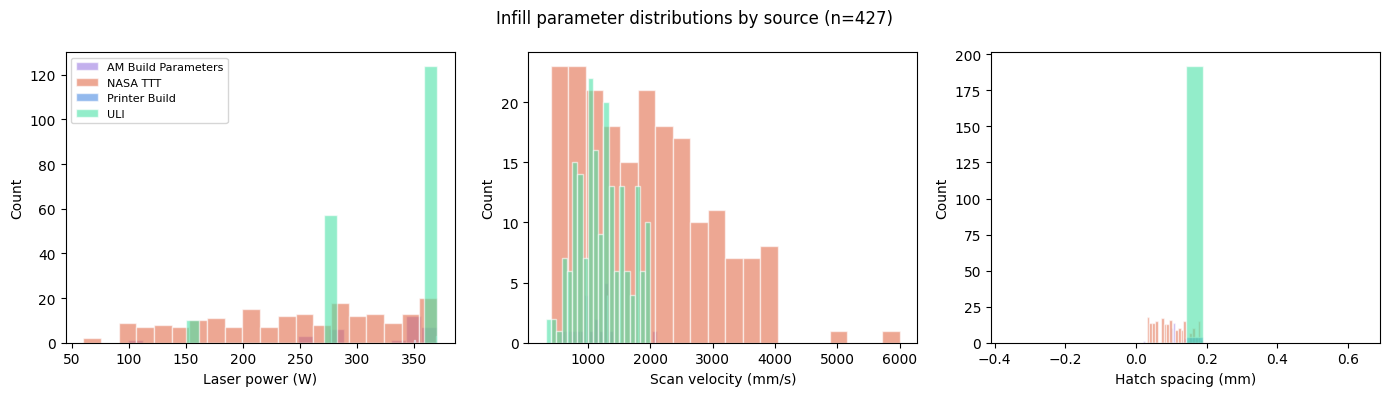

In [9]:
infill = builds[builds["scanType"] == "infill"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
palette = {"Printer Build": BLUE, "NASA TTT": ORANGE, "ULI": GREEN, "AM Build Parameters": PURPLE}

for ax, (column, label) in zip(
    axes,
    [("laserPower_W", "Laser power (W)"),
     ("laserVelocity_mm_s", "Scan velocity (mm/s)"),
     ("hatchSpacing_mm", "Hatch spacing (mm)")],
):
    for source, group in infill.groupby("source"):
        values = group[column].dropna()
        if values.empty:
            continue
        ax.hist(values, bins=20, alpha=0.6, label=source, color=palette[source],
                edgecolor="white")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")

axes[0].legend(fontsize=8)
fig.suptitle(f"Infill parameter distributions by source (n={len(infill):,})")
plt.tight_layout()
plt.show()

## Process window

Power against velocity is the conventional way to look at a process window, with energy density falling as you move down and to the right.

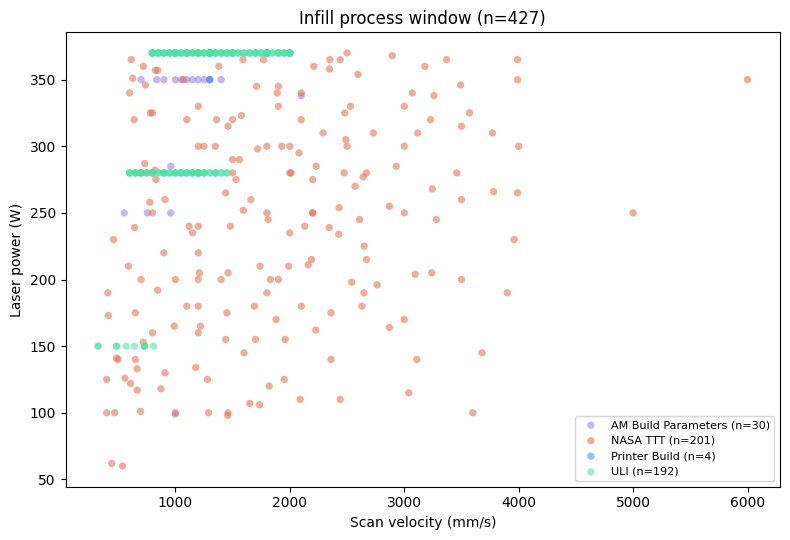

In [10]:
fig, ax = plt.subplots(figsize=(8, 5.5))

for source, group in infill.groupby("source"):
    ax.scatter(group["laserVelocity_mm_s"], group["laserPower_W"], s=28, alpha=0.55,
               label=f"{source} (n={len(group)})", color=palette[source], edgecolors="none")

ax.set_xlabel("Scan velocity (mm/s)")
ax.set_ylabel("Laser power (W)")
ax.set_title(f"Infill process window (n={len(infill):,})")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

NASA TTT spans by far the widest process window — it is a designed experiment, so that is expected. ULI clusters tightly at a few power levels, and the CMU/APL Printer Build entries sit inside the NASA envelope.

## Energy density by source

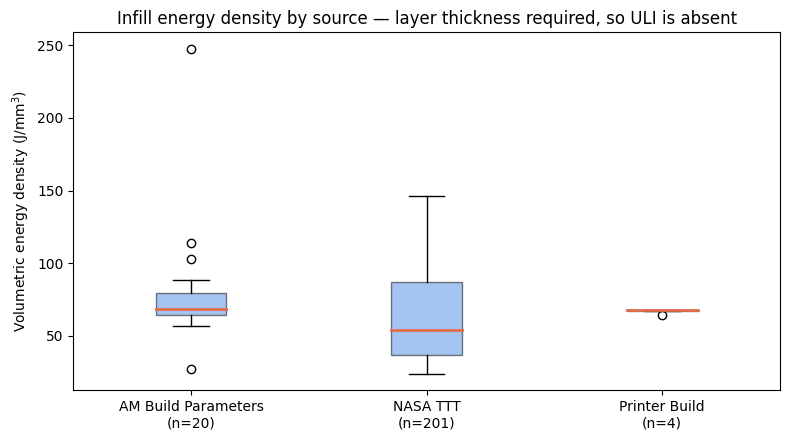

In [11]:
ved = builds[builds["VED_J_per_mm3"].notna() & (builds["scanType"] == "infill")]

fig, ax = plt.subplots(figsize=(8, 4.5))
sources = sorted(ved["source"].unique())
ax.boxplot([ved.loc[ved["source"] == s, "VED_J_per_mm3"] for s in sources],
           labels=[f"{s}\n(n={(ved['source'] == s).sum()})" for s in sources],
           patch_artist=True,
           boxprops=dict(facecolor=BLUE, alpha=0.5),
           medianprops=dict(color=ORANGE, linewidth=2))
ax.set_ylabel("Volumetric energy density (J/mm$^3$)")
ax.set_title("Infill energy density by source — layer thickness required, so ULI is absent")
plt.tight_layout()
plt.show()

ULI is missing from this chart because it records no layer thickness, so VED cannot be computed for it. That is a real gap in the archive rather than a processing choice here.

## Summary statistics

In [12]:
summary = (
    infill.groupby("source")[["hatchSpacing_mm", "laserPower_W", "laserVelocity_mm_s",
                              "layerThickness_mm", "VED_J_per_mm3"]]
    .agg(["count", "mean", "std"])
    .round(3)
)
summary

hatchSpacing_mm               laserPower_W           \
                              count   mean    std        count     mean   
source                                                                    
AM Build Parameters              30  0.109  0.022           30  322.067   
NASA TTT                        201  0.097  0.047          201  244.726   
Printer Build                     4  0.140  0.000            4  365.000   
ULI                             192  0.140  0.000          191  331.623   

                            laserVelocity_mm_s                      \
                        std              count      mean       std   
source                                                               
AM Build Parameters  59.091                 20  1105.700   327.128   
NASA TTT             82.195                201  1882.816  1022.935   
Printer Build        10.000                  4  1300.000     0.000   
ULI                  59.134                192  1227.500   392.544   

                    layerThickness_mm               VED_J_per_mm3          \
                                count   mean    std         count    mean   
source                                                                      
AM Build Parameters                30  0.035  0.006            20  80.238   
NASA TTT                          201  0.030  0.000           201  63.453   
Printer Build                       4  0.030  0.000             4  66.850   
ULI                                 0    NaN    NaN             0     NaN   

                             
                        std  
source                       
AM Build Parameters  43.158  
NASA TTT             31.885  
Printer Build         1.832  
ULI                     NaN

## Build geometries

Printer Build separately records which specimen geometries each build produced, and how many of each. This is the information the old code folded into the parameter table via a cross-product; it belongs on its own.

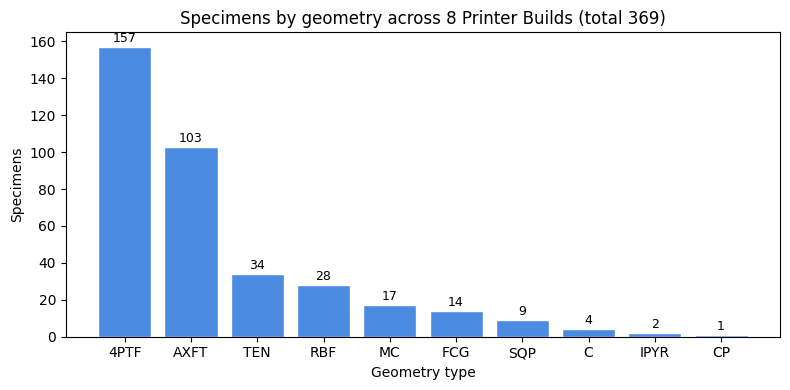

In [13]:
geometries = explode_records(by_form[PRINTER_BUILD], "buildGeometries")

by_geometry = (
    geometries.groupby("geometryType")["count"].sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(by_geometry.index, by_geometry.values, color=BLUE, edgecolor="white")
for bar, value in zip(bars, by_geometry.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{value:,}",
            ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Geometry type")
ax.set_ylabel("Specimens")
ax.set_title(f"Specimens by geometry across {geometries['uniqueId'].nunique()} Printer Builds "
             f"(total {by_geometry.sum():,})")
plt.tight_layout()
plt.show()

## Export

`results/all_infill.csv` is regenerated from the corrected frame, keeping the infill rows that earlier versions of this repo published — now with sane units, no geometry cross-product, and energy density included. Generated files go under `results/` rather than the repo root, so what is derived stays separate from what is source.

In [14]:
export = infill[["source", "uniqueId", "igsn", "hatchSpacing_mm", "laserPower_W",
                 "laserVelocity_mm_s", "layerThickness_mm", "VED_J_per_mm3"]]

results_dir = REPO_ROOT / "results"
results_dir.mkdir(exist_ok=True)
export.to_csv(results_dir / "all_infill.csv", index=False)

print(f"Wrote {len(export)} rows to results/all_infill.csv")
print(f"Hatch spacing range: {export['hatchSpacing_mm'].min():.3f} - "
      f"{export['hatchSpacing_mm'].max():.3f} mm")


Wrote 427 rows to results/all_infill.csv
Hatch spacing range: 0.020 - 0.190 mm
